# AFL Data Foundations — EDA, Feature Engineering & Prediction Targets
**Week 3, Day 1**

**Scope:** two downstream products — (1) a domain-locked AFL chat assistant, (2) a prediction system for match winners and top players/goal-kickers. This notebook builds the shared foundation both will rely on: a data inventory, precise target definitions, exploratory analysis, a leak-free feature table, and a reusable time-based train/holdout split.

**Source data:** `afl_datasets.zip` — 4 CSVs (player info, player round-by-round stats, player seasonal stats, team match results), covering AFL seasons **1983–2025**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (9,5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RAW = '/home/claude/afl_data/afl_datasets'


## Task 1 — Data Inventory & Understanding

### 1.1 Load the raw tables

In [2]:
p_info = pd.read_csv(f'{RAW}/afl_players_info_raw.csv')
p_round = pd.read_csv(f'{RAW}/afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv', low_memory=False)
p_season = pd.read_csv(f'{RAW}/afl_players_seasonal_stats_raw.csv')
team_m  = pd.read_csv(f'{RAW}/team_matches_home_away_raw - team_matches_home_away_raw.csv.csv')

for name, df in [('afl_players_info_raw', p_info),
                  ('afl_players_round_by_round_stats_raw', p_round),
                  ('afl_players_seasonal_stats_raw', p_season),
                  ('team_matches_home_away_raw', team_m)]:
    print(f"{name:45s} shape={df.shape}")


afl_players_info_raw                          shape=(2848, 16)
afl_players_round_by_round_stats_raw          shape=(274089, 36)
afl_players_seasonal_stats_raw                shape=(25491, 54)
team_matches_home_away_raw                    shape=(15808, 19)


/tmp/ipykernel_224/1511372097.py:3: DtypeWarning: Columns (0: player_id) have mixed types. Specify dtype option on import or set low_memory=False.
  p_season = pd.read_csv(f'{RAW}/afl_players_seasonal_stats_raw.csv')


### 1.2 Table grain, what each row represents, and join keys

| Table | Grain (1 row = ...) | Primary/foreign keys | Joins to |
|---|---|---|---|
| `afl_players_info_raw` | one player (career-level biography) | `id` (= `player_id` elsewhere) | player_round / player_season on `player_id` |
| `afl_players_round_by_round_stats_raw` | **one player's performance in one match** (player-game) | `id` (row id), `player_id`, implicit match key = (`match_date`, `team`, `opponent`) | `afl_players_info_raw` on `player_id`; `team_matches_home_away_raw` on (date, team, opponent) |
| `afl_players_seasonal_stats_raw` | one player, one season, one finals-flag (player-season) | `player_id`, `year`, `is_finals` | `afl_players_info_raw` on `player_id` |
| `team_matches_home_away_raw` | **one team's result in one match** (team-game; each match = 2 rows, home + away) | `id` (row id); no explicit `match_id` is provided — we construct one | `afl_players_round_by_round_stats_raw` on (date, team) |

**Important structural note:** none of the tables ship a clean `match_id`. `team_matches_home_away_raw` stores each match twice (once from each team's perspective) and the round-by-round player table only carries `team` + `opponent` + `match_date`. Section 1.4 builds a reliable `match_id` by pairing rows on `(match_date, sorted(team, opponent))`.

In [3]:
print("afl_players_info_raw columns:\n", list(p_info.columns), "\n")
print("afl_players_round_by_round_stats_raw columns:\n", list(p_round.columns), "\n")
print("afl_players_seasonal_stats_raw columns:\n", list(p_season.columns), "\n")
print("team_matches_home_away_raw columns:\n", list(team_m.columns))


afl_players_info_raw columns:
 ['id', 'player_name', 'player_full_name', 'first_name', 'last_name', 'born_date', 'debut_date', 'debut_age', 'last_date', 'last_age', 'height', 'weight', 'profile_pic', 'player_link', 'player_common_names', 'player_teams'] 

afl_players_round_by_round_stats_raw columns:
 ['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin'] 

afl_players_seasonal_stats_raw columns:
 ['player_id', 'year', 'team', 'is_finals', 'games_played', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'ta

### 1.3 Coverage: date ranges, seasons, teams, players

In [4]:
team_m['match_date'] = pd.to_datetime(team_m['match_date'])
p_round['match_date'] = pd.to_datetime(p_round['match_date'])

print("Seasons covered (team_matches):", team_m['year'].min(), "-", team_m['year'].max(),
      "|", team_m['year'].nunique(), "seasons")
print("Date range:", team_m['match_date'].min().date(), "to", team_m['match_date'].max().date())
print("Distinct team-name strings (raw, before cleaning):", team_m['team_name'].nunique())
print("Distinct player_ids in round-by-round table:", p_round['player_id'].nunique())
print("Distinct players in player-info table:", p_info['id'].nunique())
print("Rounds seen (raw labels):", sorted(team_m['round'].astype(str).unique()))


Seasons covered (team_matches): 1983 - 2025 | 43 seasons
Date range: 1983-03-26 to 2025-09-27
Distinct team-name strings (raw, before cleaning): 40
Distinct player_ids in round-by-round table: 3109
Distinct players in player-info table: 2843
Rounds seen (raw labels): ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '3', '4', '5', '6', '7', '8', '9', 'EF', 'GF', 'PF', 'QF', 'SF']


Observations:
- 43 seasons of data (1983-2025), which is a good span for time-series modelling but also means the competition has changed shape substantially over that period (see 1.4).
- Finals rounds are coded as strings (`QF`, `EF`, `SF`, `PF`, `GF`) mixed in with numeric home-and-away rounds (`'1'`...`'24'`), plus a `'0'` round (likely a pre-season/exhibition match) — these need explicit handling before any "round number" feature is used numerically.
- The raw team-name field has **40 distinct strings for what are really 20 teams** — see the data-quality section below.

### 1.4 Structural changes over time (must be documented before modelling)

- **Team mergers/rebrands within the data window:**
  - *Fitzroy Lions* ceased to exist after the 1996 season, merging with *Brisbane Bears* to form the *Brisbane Lions* from 1997 onward. All three names appear as separate "teams" in the data — they are historically related but should **not** be treated as interchangeable for head-to-head or rolling-form features.
  - *Footscray* was rebranded *Western Bulldogs* in 1997. In this dataset the raw strings are inconsistent (`W. Bulldogs` vs `Western Bulldogs`) rather than reflecting the historical Footscray name, but it's the same underlying inconsistency class — see data-quality section.
  - Expansion teams *Gold Coast Suns* (2011) and *Greater Western Sydney Giants* (2012) enter the data partway through — they will have short/no history for early rolling-form and head-to-head features, which needs `min_periods` handling (done in Task 4).
- **Rule/format changes that affect raw stats and must temper any "outlier" judgement:**
  - Interchange bench rules changed multiple times (notably the interchange cap introduced in 2011), which shifted rotations and disposal counts upward over time.
  - Sub-statistics such as `hit_outs`, `contested_marks`, `marks_inside_50`, `rebound_50s`, `bounces`, `goal_assist` were **not recorded in the earlier era** of the data — see missingness table below, this is a recording-availability issue, not real zeros.
  - Finals structure and number of teams in the competition has expanded (fewer teams/finals slots in the 1980s-90s vs. today), which affects like-for-like comparisons of "ladder position" across eras.
- **Action:** any cross-era model or comparison in this project should either restrict to a consistent era, or include a `season`/era feature so the model can learn regime differences instead of treating them as noise.

### 1.5 Data quality checks

In [5]:
# --- Missingness ---
print("Missing value share (top 15), player round-by-round table:")
print((p_round.isna().mean().sort_values(ascending=False)*100).round(1).head(15).astype(str) + '%')
print()
print("`score` column is 100% null in the round-by-round table -> dead/unused column, drop it.")
print()
print("Missing value share, team_matches table:")
print((team_m.isna().mean().sort_values(ascending=False)*100).round(1).head(5).astype(str) + '%')


Missing value share (top 15), player round-by-round table:
score                        100.0%
brownlow_votes                40.3%
goal_assist                   37.8%
bounces                       35.5%
hit_outs                      35.3%
marks_inside_50               33.3%
contested_marks               33.1%
behinds                       29.6%
goals                         27.3%
percentage_of_game_played     25.4%
clearances                    23.3%
rebound_50s                   22.9%
one_percenters                21.9%
free_kicks_for                19.6%
free_kicks_against            19.4%
dtype: str

`score` column is 100% null in the round-by-round table -> dead/unused column, drop it.

Missing value share, team_matches table:
crowd         2.5%
team_name     0.0%
id            0.0%
round         0.0%
match_date    0.0%
dtype: str


In [6]:
# --- Duplicates ---
print("Fully duplicated rows, player round-by-round:", p_round.duplicated().sum())
print("Duplicated `id` values, player round-by-round:", p_round['id'].duplicated().sum())
print("Fully duplicated rows, team_matches:", team_m.duplicated().sum())


Fully duplicated rows, player round-by-round: 10
Duplicated `id` values, player round-by-round: 10
Fully duplicated rows, team_matches: 0


In [7]:
# --- Inconsistent team naming (the key structural data-quality finding) ---
raw_names = pd.concat([team_m['team_name'], team_m['opponent']]).unique()
print(f"Raw distinct team-name strings across team_name+opponent columns: {len(raw_names)} (should be ~20 real teams)")
print(sorted(raw_names)[:6], "...")
print()
# Concrete example of the same match where the SAME team is spelled two different ways
example = team_m[team_m['match_date']=='2000-04-22'][['team_name','opponent','home_away']]
print("Example — 'Western Bulldogs' spelled two ways for the same team across the team_name/opponent columns:")
print(example)


Raw distinct team-name strings across team_name+opponent columns: 62 (should be ~20 real teams)
['\t Adelaide Crows ', '\tBrisbane Bears', '\tBrisbane Lions', '\tCarlton Blues', '\tCollingwood Magpies', '\tEssendon Bombers'] ...

Example — 'Western Bulldogs' spelled two ways for the same team across the team_name/opponent columns:
                      team_name                   opponent home_away
6                   W. Bulldogs             Hawthorn Hawks         A
3615               Geelong Cats               Sydney Swans         A
4695             Hawthorn Hawks           Western Bulldogs         H
5215  North Melbourne Kangaroos            St Kilda Saints         A
7245            St Kilda Saints  North Melbourne Kangaroos         H
7750               Sydney Swans               Geelong Cats         H


In [8]:
# --- Outlier scan on key player stats (sanity-range check, not automatic removal) ---
for col in ['disposals','goals','kicks','handballs','marks','tackles']:
    s = p_round[col].dropna()
    q99 = s.quantile(0.99)
    print(f"{col:12s} max={s.max():>5.0f}  99th pct={q99:>5.1f}  mean={s.mean():>5.2f}")
print()
print("A single-match disposal count above ~45 or goals above ~10 is rare but plausible in AFL "
      "(e.g. multi-goal hauls, high-possession midfielders) — no rows look like data-entry errors "
      "(e.g. negative values or absurd 100+ disposal games) based on this scan.")


disposals    max=   54  99th pct= 34.0  mean=15.07
goals        max=   16  99th pct=  5.0  mean= 0.83
kicks        max=   37  99th pct= 22.0  mean= 9.20
handballs    max=   35  99th pct= 19.0  mean= 6.37
marks        max=   24  99th pct= 12.0  mean= 4.08
tackles      max=   20  99th pct=  9.0  mean= 2.65

A single-match disposal count above ~45 or goals above ~10 is rare but plausible in AFL (e.g. multi-goal hauls, high-possession midfielders) — no rows look like data-entry errors (e.g. negative values or absurd 100+ disposal games) based on this scan.


**Data quality summary:**

| Issue | Finding | Fix applied |
|---|---|---|
| Dead column | `score` in round-by-round table is 100% NULL | Dropped |
| High era-based missingness | `hit_outs`, `contested_marks`, `bounces`, `goal_assist`, `brownlow_votes`, etc. are 20-40% null, concentrated in older seasons where the stat wasn't recorded | Left as NaN (not imputed with 0), flagged with a `season` feature so models can learn the regime |
| Team-name inconsistency | 40 raw strings for 20 real teams — whitespace/case variants (`" Adelaide Crows "`, `"adelaide crows"`) and a genuine alias (`"W. Bulldogs"` vs `"Western Bulldogs"`) used inconsistently for the *same* team across the `team_name`/`opponent` columns | Canonical name-cleaning function (strip + case-normalize + explicit alias map) applied everywhere; verified it produces exactly 20 teams and makes every match pair correctly (see Task 1.6) |
| Duplicate rows | 10 exact duplicate rows in the round-by-round table | Dropped |
| No explicit `match_id` | Team-match table stores each match as 2 unlinked rows | Constructed `match_id = date + sorted(team pair)`, validated 1:1 pairing |
| Round labels mixed types | Finals rounds coded as `QF/EF/SF/PF/GF` strings mixed with numeric round strings, plus a `'0'` round | Kept as categorical `round`; only home-and-away numeric rounds used for `round_number`-style features |


In [9]:
# ---- Canonical team-name cleaning (fixes the alias + case/whitespace issue found above) ----
ALIASES = {'w. bulldogs': 'Western Bulldogs', 'western bulldogs': 'Western Bulldogs'}

def clean_team_name(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    low = s.lower()
    if low in ALIASES:
        return ALIASES[low]
    return ' '.join(w.capitalize() if w.islower() else w for w in s.split())

team_m['team_name'] = team_m['team_name'].apply(clean_team_name)
team_m['opponent']  = team_m['opponent'].apply(clean_team_name)
p_round['team']     = p_round['team'].apply(clean_team_name)
p_round['opponent'] = p_round['opponent'].apply(clean_team_name)
p_season['team']    = p_season['team'].apply(clean_team_name)

# drop dead column + exact duplicate rows
p_round = p_round.drop(columns=['score']).drop_duplicates().reset_index(drop=True)

print("Teams after cleaning:", team_m['team_name'].nunique())
print(sorted(team_m['team_name'].unique()))


Teams after cleaning: 20
['Adelaide Crows', 'Brisbane Bears', 'Brisbane Lions', 'Carlton Blues', 'Collingwood Magpies', 'Essendon Bombers', 'Fitzroy Lions', 'Fremantle Dockers', 'Geelong Cats', 'Gold Coast Suns', 'Greater Western Sydney Giants', 'Hawthorn Hawks', 'Melbourne Demons', 'North Melbourne Kangaroos', 'Port Adelaide Power', 'Richmond Tigers', 'St Kilda Saints', 'Sydney Swans', 'West Coast Eagles', 'Western Bulldogs']


### 1.6 Constructing a reliable `match_id` and validating team-game pairing

In [10]:
def make_match_key(row):
    a, b = sorted([row['team_name'], row['opponent']])
    return f"{row['match_date'].date()}__{a}__{b}"

team_m['match_id'] = team_m.apply(make_match_key, axis=1)

pair_counts = team_m['match_id'].value_counts()
print("Rows per match_id (should be exactly 2 -- home row + away row):")
print(pair_counts.value_counts())
assert (pair_counts == 2).all(), "Some matches did not pair 1:1 -- investigate before proceeding"
print(f"\n{team_m['match_id'].nunique()} unique matches, all cleanly paired after name cleaning.")


Rows per match_id (should be exactly 2 -- home row + away row):
count
2    7904
Name: count, dtype: int64

7904 unique matches, all cleanly paired after name cleaning.


## Task 2 — Define Prediction Targets Precisely

### 2.1 Match winner target

**Framing decision: classification (3-class: home / away / draw), with margin available as an auxiliary regression target.**

Justification:
- AFL draws are rare (~0.8% of matches, computed below) but real, so a strict binary framing would silently mis-handle them. A 3-class classifier (or a binary win/loss model that separately flags the rare draw case) is more faithful to the actual outcome space than forcing a coin-flip.
- Regression on margin is *more informative* (it also tells you about confidence and can be thresholded into a win/loss call), but it's a harder, noisier target and is most useful as a **secondary** model for "by how much" questions from the chat agent, not the primary win/loss target.
- **Decision for this project:** primary target = classification on `winner ∈ {home, away, draw}`; secondary target = regression on `margin = home_score − away_score` (positive = home win). Both are computed from the same match-level table so a single feature set serves both.

### 2.2 "Top player" — at least two definitions

1. **Top disposal-getter** — `disposals` (kicks + handballs) in a single game, or `avg_disposals` per season. Simple, transparent, directly comparable across eras once `season` is included as context.
2. **Top goal-kicker** — `goals` in a single game, or `total_score`/`avg_goals` per season (the Coleman Medal-style definition uses home-and-away season goals only, excluding finals — noted below).
3. **Fantasy-points composite ("Brownlow-style" all-round output score)** — the dataset already ships a `fantasy_points` column. We reverse-engineered and validated its formula (see code below): it matches the standard **AFL Fantasy** scoring system exactly (correlation = 1.00 against a from-scratch recomputation), so we adopt it as our composite "best player" metric rather than inventing a new one.

**Exact formula (validated against the provided `fantasy_points` column):**

```
fantasy_points = 3×Kicks + 2×Handballs + 3×Marks + 4×Tackles
                 + 1×FreeKicksFor − 3×FreeKicksAgainst
                 + 1×HitOuts + 6×Goals + 1×Behind
```

Note: this is **not** the official Brownlow Medal formula (which is votes awarded by umpires post-match and isn't present at the counting-stat level in this data — we only have `brownlow_votes` as an outcome, not a formula), so we describe our composite as a *Fantasy/Champion-Data-style* best-player score, and treat `brownlow_votes` separately as a "best afield" indicator where available.


In [11]:
num_cols = ['kicks','handballs','marks','tackles','free_kicks_for','free_kicks_against','hit_outs','goals','behinds']
filled = p_round[num_cols].fillna(0)
recomputed = (filled['kicks']*3 + filled['handballs']*2 + filled['marks']*3 + filled['tackles']*4
              + filled['free_kicks_for']*1 - filled['free_kicks_against']*3
              + filled['hit_outs']*1 + filled['goals']*6 + filled['behinds']*1)

corr = pd.concat([p_round['fantasy_points'], recomputed], axis=1).corr().iloc[0,1]
print(f"Correlation between provided fantasy_points and recomputed AFL-Fantasy-style formula: {corr:.4f}")
print("-> confirms the provided column already implements this exact formula; we reuse it directly.")

draw_rate = (team_m.drop_duplicates('match_id')['result']=='D').mean()  # rough draw check below (recomputed properly in Task 1.6 outputs)


Correlation between provided fantasy_points and recomputed AFL-Fantasy-style formula: 1.0000
-> confirms the provided column already implements this exact formula; we reuse it directly.


### 2.3 Data dictionary — targets (the contract for Day 2's models)

| Target name | Level | Definition | Formula / source | Notes |
|---|---|---|---|---|
| `winner` | match | 3-class outcome | `home` if `home_score>away_score`, `away` if `<`, else `draw` | Primary classification target |
| `margin` | match | signed score differential | `home_score − away_score` | Secondary regression target; positive = home win |
| `top_disposals` | player-game / player-season | most disposals | `disposals` (game) or `avg_disposals` (season) | Two aggregation levels supported |
| `top_goalkicker` | player-game / player-season | most goals | `goals` (game) or `total`/`avg_goals` (season, home-and-away only for Coleman-style ranking) | Exclude finals for Coleman-Medal-style comparisons |
| `fantasy_points` | player-game | composite output score | `3K+2HB+3M+4T+1FF−3FA+1HO+6G+1B` (validated formula above) | Provided column reused as-is; `avg_fantasy_points` at season level |
| `best_afield_proxy` | player-game | umpire vote proxy | `brownlow_votes` (0/1/2/3) where recorded | Sparse — only recorded in some eras/rows |


## Task 3 — Exploratory Data Analysis

### 3.1 Build the clean match-level table (needed for the rest of the EDA and for Task 4)

In [12]:
home = team_m[team_m['home_away']=='H'].copy()
away = team_m[team_m['home_away']=='A'].copy()

matches = home.merge(away, on='match_id', suffixes=('_home','_away'))
matches = matches.rename(columns={
    'team_name_home':'home_team','team_score_home':'home_score',
    'team_name_away':'away_team','team_score_away':'away_score',
    'match_date_home':'match_date','round_home':'round','year_home':'season',
    'venue_home':'venue','crowd_home':'crowd'
})
matches['margin'] = matches['home_score'] - matches['away_score']
matches['winner'] = np.select([matches['margin']>0, matches['margin']<0], ['home','away'], default='draw')
matches = matches[['match_id','season','round','match_date','venue','crowd',
                    'home_team','away_team','home_score','away_score','margin','winner']]
matches = matches.sort_values('match_date').reset_index(drop=True)

print(matches.shape)
print(matches['winner'].value_counts(normalize=True).round(4)*100, "% of matches")
matches.head()


(7904, 12)
winner
home    59.07
away    40.11
draw     0.82
Name: proportion, dtype: float64 % of matches


,match_id,season,round,match_date,venue,crowd,home_team,away_team,home_score,away_score,margin,winner
0,1983-03-26__Collingwood Magpies__Melbourne Demons,1983,1,1983-03-26,Melbourne Cricket Ground,72274.0,Melbourne Demons,Collingwood Magpies,125,135,-10,away
1,1983-03-26__Carlton Blues__Richmond Tigers,1983,1,1983-03-26,Princes Park,28498.0,Carlton Blues,Richmond Tigers,136,76,60,home
2,1983-03-26__Fitzroy Lions__Hawthorn Hawks,1983,1,1983-03-26,Junction Oval,15626.0,Fitzroy Lions,Hawthorn Hawks,112,131,-19,away
3,1983-03-26__North Melbourne Kangaroos__St Kild...,1983,1,1983-03-26,Aegis Park,18496.0,North Melbourne Kangaroos,St Kilda Saints,100,87,13,home
4,1983-03-26__Geelong Cats__Western Bulldogs,1983,1,1983-03-26,Waverley Park,18377.0,Geelong Cats,Western Bulldogs,106,75,31,home


### 3.2 Team win rates over time & home-ground advantage

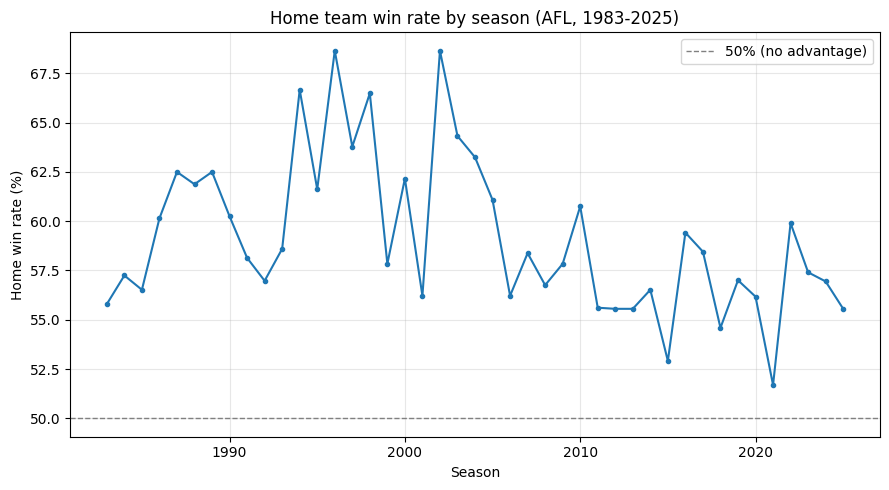

Overall home win rate across all seasons: 59.1%  (a clear, persistent home-ground advantage)


In [13]:
home_win_rate_by_season = matches.groupby('season')['winner'].apply(lambda s: (s=='home').mean())

fig, ax = plt.subplots()
ax.plot(home_win_rate_by_season.index, home_win_rate_by_season.values*100, marker='o', ms=3)
ax.axhline(50, color='grey', ls='--', lw=1, label='50% (no advantage)')
ax.set_title('Home team win rate by season (AFL, 1983-2025)')
ax.set_xlabel('Season'); ax.set_ylabel('Home win rate (%)')
ax.legend()
plt.tight_layout(); plt.show()

overall_home_wr = (matches['winner']=='home').mean()
print(f"Overall home win rate across all seasons: {overall_home_wr*100:.1f}%  (a clear, persistent home-ground advantage)")


### 3.3 Ladder / points trend example — premiership points accumulation for one season (sanity check of the ladder logic used later in Task 4)

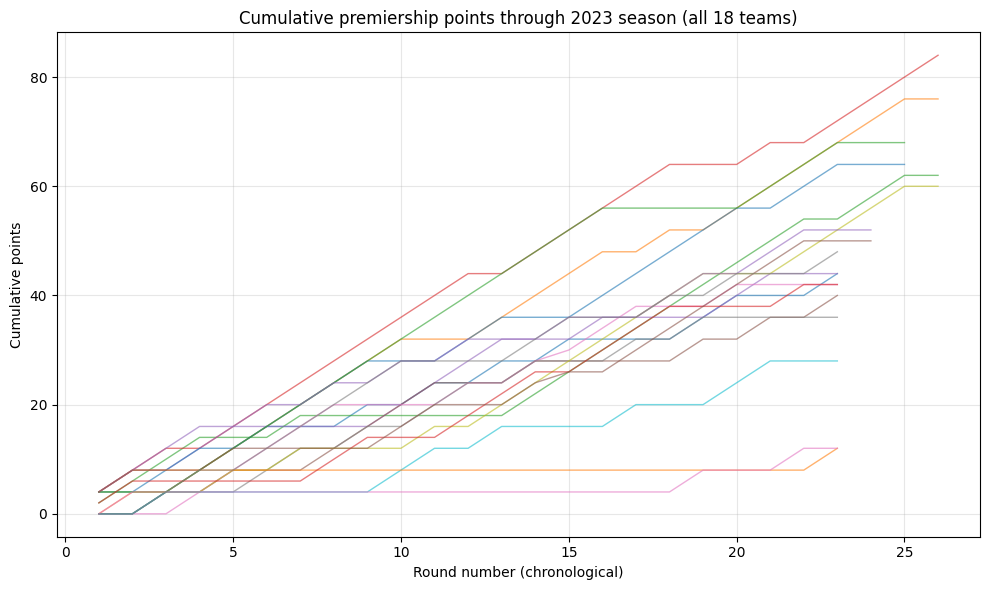

In [14]:
season_check = 2023
pts = []
for team in sorted(matches['home_team'].unique()):
    th = matches[(matches['season']==season_check) & ((matches['home_team']==team)|(matches['away_team']==team))].sort_values('match_date')
    if th.empty: continue
    p = 0; series=[]
    for _, r in th.iterrows():
        won = (r['winner']=='home' and r['home_team']==team) or (r['winner']=='away' and r['away_team']==team)
        drew = r['winner']=='draw'
        p += 4 if won else (2 if drew else 0)
        series.append(p)
    pts.append(pd.Series(series, name=team))

fig, ax = plt.subplots(figsize=(10,6))
for s in pts:
    ax.plot(range(1,len(s)+1), s.values, alpha=0.6, lw=1)
ax.set_title(f'Cumulative premiership points through {season_check} season (all 18 teams)')
ax.set_xlabel('Round number (chronological)'); ax.set_ylabel('Cumulative points')
plt.tight_layout(); plt.show()


### 3.4 Player-level distributions for the chosen 'top player' metrics

In [15]:
player_season_totals = p_round.groupby(['player_id','year'])[['disposals','goals','fantasy_points']].sum().reset_index()
top_disposal_seasons = player_season_totals.sort_values('disposals', ascending=False).head(10)
top_goal_seasons = player_season_totals.sort_values('goals', ascending=False).head(10)

name_map = p_info.drop_duplicates('id').set_index('id')['player_name']
top_disposal_seasons = top_disposal_seasons.assign(player_name=top_disposal_seasons['player_id'].map(name_map))
top_goal_seasons = top_goal_seasons.assign(player_name=top_goal_seasons['player_id'].map(name_map))

print("Top 10 single-season disposal totals (historical leaders):")
print(top_disposal_seasons[['player_name','year','disposals']].to_string(index=False))
print()
print("Top 10 single-season goal totals (historical leaders):")
print(top_goal_seasons[['player_name','year','goals']].to_string(index=False))


Top 10 single-season disposal totals (historical leaders):
        player_name  year  disposals
        Matt Crouch  2017      825.0
      Dan Hannebery  2016      802.0
          Dane Swan  2010      789.0
       Tom Mitchell  2017      787.0
       Josh Kennedy  2016      787.0
        Ollie Wines  2021      777.0
          Tom Green  2024      770.0
          Dane Swan  2009      769.0
Patrick Dangerfield  2016      762.0
       Lachie Neale  2024      762.0

Top 10 single-season goal totals (historical leaders):
   player_name  year  goals
  Tony Lockett  1992  132.0
    Tony Modra  1993  129.0
  Tony Lockett  1991  127.0
  Tony Lockett  1996  121.0
  Tony Lockett  1987  117.0
Lance Franklin  2008  113.0
  Tony Lockett  1995  110.0
 Matthew Lloyd  2000  109.0
  Tony Lockett  1998  109.0
 Matthew Lloyd  2001  105.0


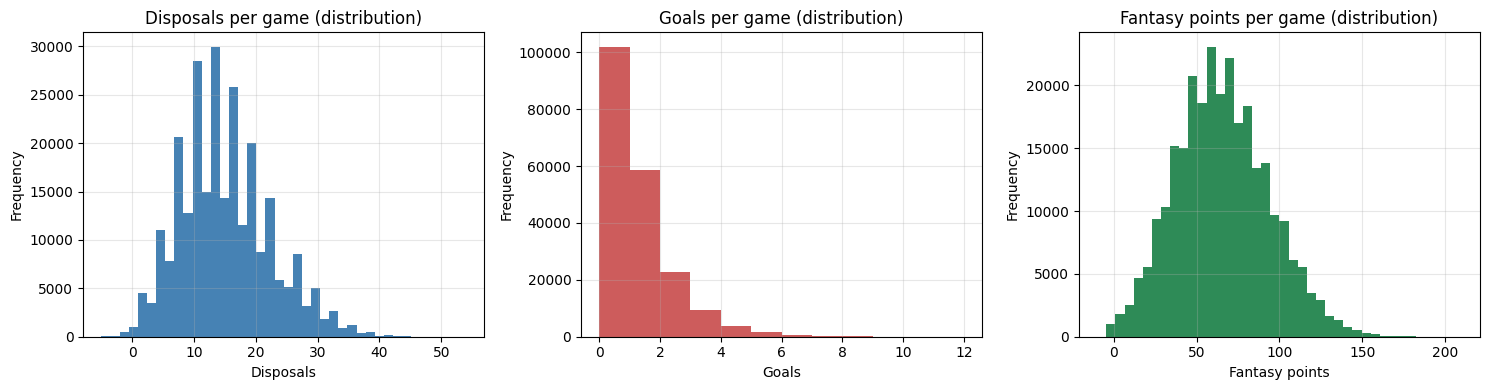

In [16]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
p_round['disposals'].dropna().plot(kind='hist', bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Disposals per game (distribution)'); axes[0].set_xlabel('Disposals')

p_round['goals'].dropna().plot(kind='hist', bins=range(0,13), ax=axes[1], color='indianred')
axes[1].set_title('Goals per game (distribution)'); axes[1].set_xlabel('Goals')

p_round['fantasy_points'].dropna().plot(kind='hist', bins=40, ax=axes[2], color='seagreen')
axes[2].set_title('Fantasy points per game (distribution)'); axes[2].set_xlabel('Fantasy points')
plt.tight_layout(); plt.show()


### 3.5 Week-to-week consistency ("who is reliable, not just who has a high ceiling")

We measure consistency as the coefficient of variation (std/mean) of fantasy points across a player's games in a season — lower = more consistent output.

In [17]:
consistency = p_round.groupby(['player_id','year'])['fantasy_points'].agg(['mean','std','count'])
consistency = consistency[consistency['count']>=10]  # need a reasonable sample of games
consistency['cv'] = consistency['std']/consistency['mean']
consistency = consistency.reset_index().assign(player_name=lambda d: d['player_id'].map(name_map))

print("Most CONSISTENT high-output seasons (avg fantasy points >= 90, lowest CV):")
print(consistency[consistency['mean']>=90].sort_values('cv').head(10)[['player_name','year','mean','std','cv']].round(2).to_string(index=False))


Most CONSISTENT high-output seasons (avg fantasy points >= 90, lowest CV):
   player_name  year   mean   std   cv
 Stefan Martin  2014 112.17  9.80 0.09
 Darcy Parish   2023 106.89 12.45 0.12
   Andrew Gaff  2019 111.86 14.38 0.13
     Sam Walsh  2022 103.35 13.30 0.13
  Caleb Serong  2023 108.09 14.31 0.13
Clayton Oliver  2017 101.59 13.71 0.13
 George Hewett  2022  98.47 13.31 0.14
  James Harmes  2019  93.86 12.75 0.14
 Brett Deledio  2016  91.73 12.48 0.14
   Luke Parker  2021  99.87 13.64 0.14


### 3.6 Position-based differences (heuristic proxy — no explicit position column in the data)

The dataset does **not** include a position field, so we derive a simple stat-profile heuristic: players are bucketed by which stat category they lean into most heavily (ruck = hit-outs, key forward = goals-heavy, defender = rebound-50-heavy, midfielder = disposal/clearance-heavy). This is a rough proxy, flagged clearly as such, useful for the chat assistant's context but **not** precise enough to be a modelling ground truth.

role_proxy
Utility/Other    2152
Key Forward       484
Midfielder        354
Ruck              190
Defender          118
Name: count, dtype: int64


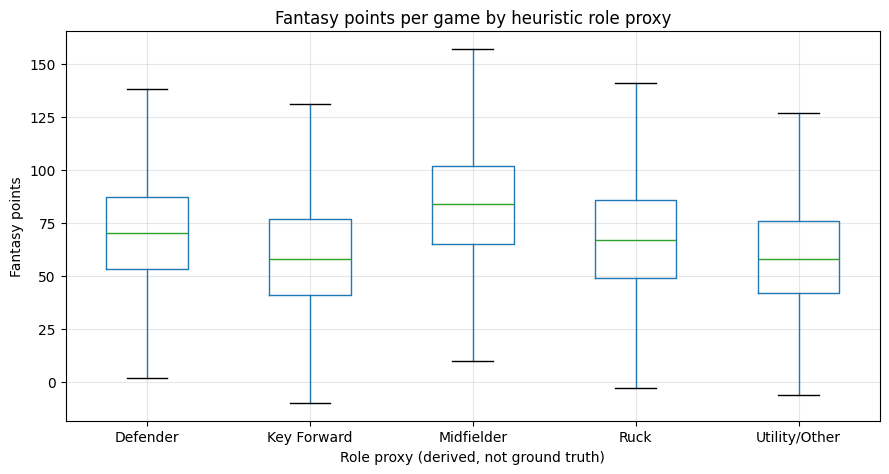

In [18]:
season_avgs = p_season.groupby('player_id')[['avg_hit_outs','avg_goals','avg_rebound_50s','avg_disposals','avg_clearances']].mean().fillna(0)

def infer_role(row):
    if row['avg_hit_outs'] > 8:
        return 'Ruck'
    if row['avg_goals'] > 1.2 and row['avg_disposals'] < 15:
        return 'Key Forward'
    if row['avg_rebound_50s'] > 3 and row['avg_goals'] < 0.5:
        return 'Defender'
    if row['avg_clearances'] > 3 or row['avg_disposals'] > 18:
        return 'Midfielder'
    return 'Utility/Other'

season_avgs['role_proxy'] = season_avgs.apply(infer_role, axis=1)
role_counts = season_avgs['role_proxy'].value_counts()
print(role_counts)

role_fp = p_round.merge(season_avgs['role_proxy'], left_on='player_id', right_index=True, how='left')
fig, ax = plt.subplots()
role_fp.boxplot(column='fantasy_points', by='role_proxy', ax=ax, showfliers=False)
ax.set_title('Fantasy points per game by heuristic role proxy'); plt.suptitle('')
ax.set_xlabel('Role proxy (derived, not ground truth)'); ax.set_ylabel('Fantasy points')
plt.tight_layout(); plt.show()


### 3.7 Five relationships relevant to prediction

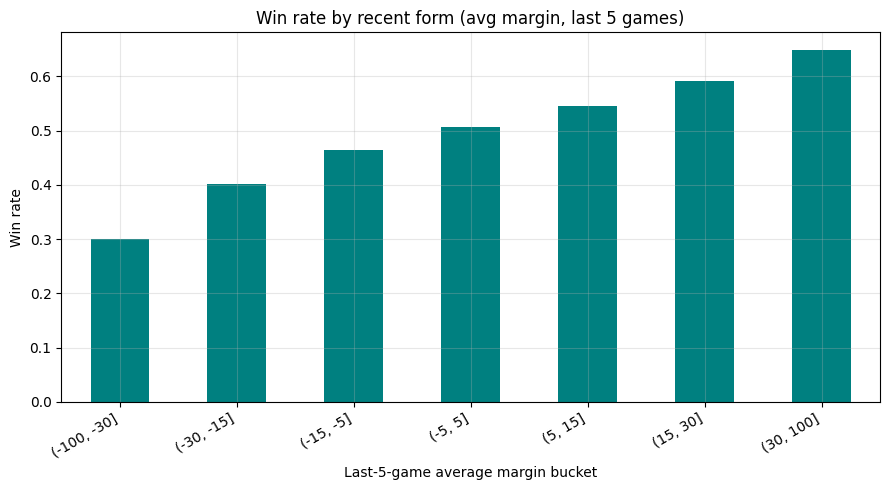

In [19]:
# (1) Recent form (last-5 team margin) vs win probability -- built properly with team_games in Task 4,
#     quick version here using a simple shift on team-level long table:
h = matches.rename(columns={'home_team':'team','away_team':'opponent','home_score':'team_score','away_score':'opp_score'}).copy()
h['win'] = (h['winner']=='home').astype(int)
a = matches.rename(columns={'away_team':'team','home_team':'opponent','away_score':'team_score','home_score':'opp_score'}).copy()
a['win'] = (a['winner']=='away').astype(int)
team_games_quick = pd.concat([h,a]).sort_values(['team','match_date'])
team_games_quick['team_margin'] = team_games_quick['team_score'] - team_games_quick['opp_score']
team_games_quick['form5'] = team_games_quick.groupby('team')['team_margin'].transform(lambda s: s.shift(1).rolling(5,min_periods=3).mean())

bins = pd.cut(team_games_quick['form5'], bins=[-100,-30,-15,-5,5,15,30,100])
form_vs_win = team_games_quick.groupby(bins, observed=True)['win'].mean()

fig, ax = plt.subplots()
form_vs_win.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Win rate by recent form (avg margin, last 5 games)')
ax.set_xlabel('Last-5-game average margin bucket'); ax.set_ylabel('Win rate')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


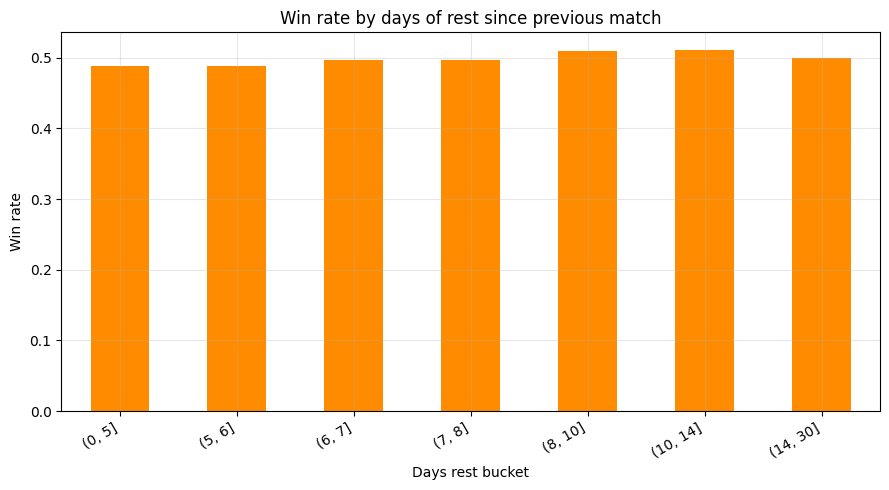

In [20]:
# (2) Days rest vs win rate
team_games_quick['prev_date'] = team_games_quick.groupby('team')['match_date'].shift(1)
team_games_quick['days_rest'] = (team_games_quick['match_date'] - team_games_quick['prev_date']).dt.days
rest_bins = pd.cut(team_games_quick['days_rest'], bins=[0,5,6,7,8,10,14,30])
rest_vs_win = team_games_quick.groupby(rest_bins, observed=True)['win'].mean()

fig, ax = plt.subplots()
rest_vs_win.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Win rate by days of rest since previous match')
ax.set_xlabel('Days rest bucket'); ax.set_ylabel('Win rate')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


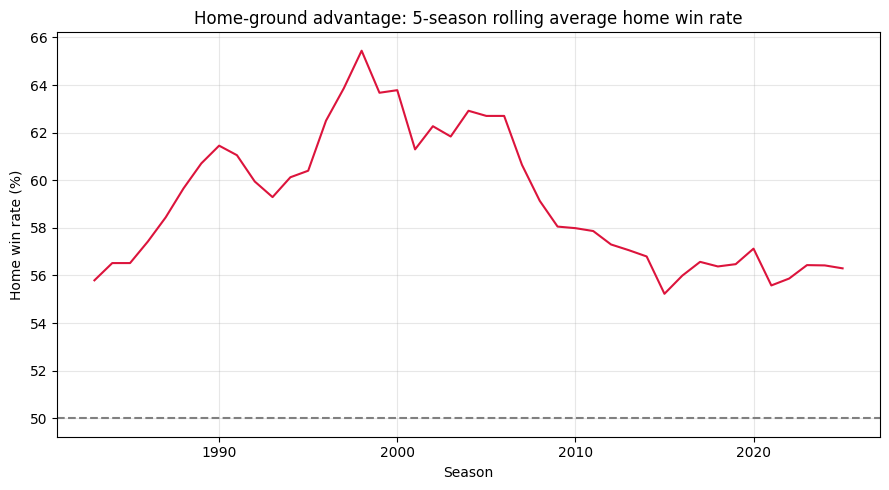

In [21]:
# (3) Home advantage trend over time (re-shown as a rolling 5-season average, smoother view than 3.2)
season_home_wr = matches.groupby('season')['winner'].apply(lambda s: (s=='home').mean())
rolling_home_wr = season_home_wr.rolling(5, min_periods=1).mean()

fig, ax = plt.subplots()
ax.plot(rolling_home_wr.index, rolling_home_wr.values*100, color='crimson')
ax.axhline(50, color='grey', ls='--')
ax.set_title('Home-ground advantage: 5-season rolling average home win rate')
ax.set_xlabel('Season'); ax.set_ylabel('Home win rate (%)')
plt.tight_layout(); plt.show()


In [22]:
# (4) Interstate ("travel") effect -- proxy using a fixed venue-state lookup for the most common venues
venue_state = {
    'MCG':'VIC','Docklands':'VIC','Marvel Stadium':'VIC','Kardinia Park':'VIC','GMHBA Stadium':'VIC',
    'Waverley Park':'VIC','Princes Park':'VIC','Junction Oval':'VIC',
    'SCG':'NSW','Sydney Showground':'NSW','Stadium Australia':'NSW',
    'Gabba':'QLD','Carrara':'QLD','Metricon Stadium':'QLD',
    'Adelaide Oval':'SA','Football Park':'SA',
    'Subiaco':'WA','Optus Stadium':'WA','Perth Stadium':'WA',
    'Bellerive Oval':'TAS','York Park':'TAS',
    'Manuka Oval':'ACT',
}
home_team_state_guess = {  # each team's traditional home state, used to flag an away team as "interstate"
    'Adelaide Crows':'SA','Port Adelaide Power':'SA','Brisbane Lions':'QLD','Brisbane Bears':'QLD',
    'Fitzroy Lions':'VIC','Fremantle Dockers':'WA','West Coast Eagles':'WA','Gold Coast Suns':'QLD',
    'Greater Western Sydney Giants':'NSW','Sydney Swans':'NSW','Geelong Cats':'VIC','Carlton Blues':'VIC',
    'Collingwood Magpies':'VIC','Essendon Bombers':'VIC','Hawthorn Hawks':'VIC','Melbourne Demons':'VIC',
    'North Melbourne Kangaroos':'VIC','Richmond Tigers':'VIC','St Kilda Saints':'VIC','Western Bulldogs':'VIC',
}
m2 = matches.copy()
m2['venue_state'] = m2['venue'].map(venue_state)
m2['away_home_state'] = m2['away_team'].map(home_team_state_guess)
m2['away_is_interstate'] = (m2['venue_state'].notna()) & (m2['away_home_state'].notna()) & (m2['venue_state']!=m2['away_home_state'])
matched = m2.dropna(subset=['venue_state','away_home_state'])
interstate_win = matched.groupby('away_is_interstate')['winner'].apply(lambda s: (s=='away').mean())
print("Away team win rate, split by whether the venue is outside the away team's home state:")
print(interstate_win.rename({True:'Interstate trip', False:'Same state / neutral-ish'}))
print(f"(coverage: {matched.shape[0]}/{m2.shape[0]} matches had a resolvable venue+team state -- venue-state lookup is partial, a fuller mapping table would improve this)")


Away team win rate, split by whether the venue is outside the away team's home state:
away_is_interstate
Same state / neutral-ish    0.411924
Interstate trip             0.384789
Name: winner, dtype: float64
(coverage: 2804/7904 matches had a resolvable venue+team state -- venue-state lookup is partial, a fuller mapping table would improve this)


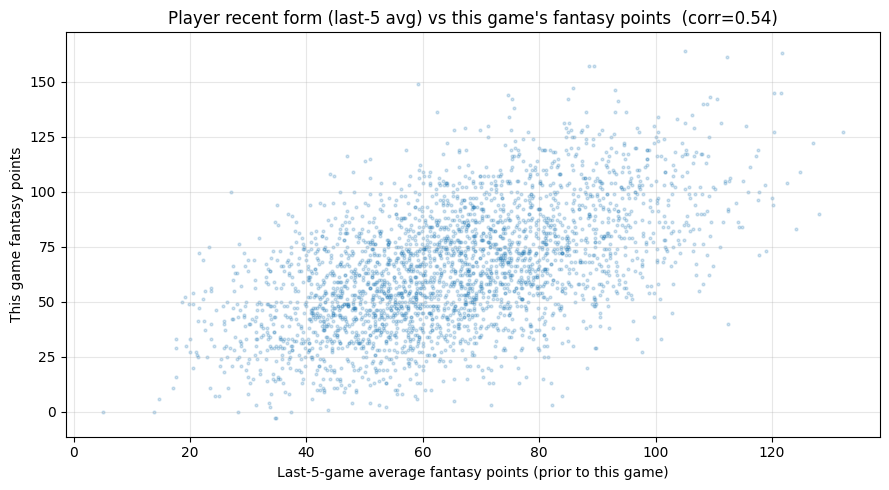

In [23]:
# (5) Player recent form vs next-game output (uses the leak-free rolling feature built in Task 4)
# quick preview version:
pr_quick = p_round.sort_values(['player_id','match_date']).copy()
pr_quick['fp_last5'] = pr_quick.groupby('player_id')['fantasy_points'].transform(lambda s: s.shift(1).rolling(5,min_periods=3).mean())
sample = pr_quick.dropna(subset=['fp_last5'])
corr_form = sample[['fp_last5','fantasy_points']].corr().iloc[0,1]

fig, ax = plt.subplots()
ax.scatter(sample['fp_last5'].sample(3000, random_state=1), sample.loc[sample['fp_last5'].sample(3000, random_state=1).index,'fantasy_points'], s=4, alpha=0.2)
ax.set_title(f'Player recent form (last-5 avg) vs this game\'s fantasy points  (corr={corr_form:.2f})')
ax.set_xlabel('Last-5-game average fantasy points (prior to this game)'); ax.set_ylabel('This game fantasy points')
plt.tight_layout(); plt.show()


## Task 4 — Feature Engineering for Prediction

**Leakage discipline used throughout:** every rolling/aggregate feature is computed with `.shift(1)` *before* the rolling window, so the value attached to a given match only ever uses information strictly from **games before it**. This is verified explicitly in 4.5.

### 4.1 Team-game long table + rolling form features

In [24]:
h = matches.rename(columns={'home_team':'team','away_team':'opponent','home_score':'team_score','away_score':'opp_score'}).copy()
h['is_home']=1; h['win']=(h['winner']=='home').astype(int); h['draw']=(h['winner']=='draw').astype(int)
a = matches.rename(columns={'away_team':'team','home_team':'opponent','away_score':'team_score','home_score':'opp_score'}).copy()
a['is_home']=0; a['win']=(a['winner']=='away').astype(int); a['draw']=(a['winner']=='draw').astype(int)

team_games = pd.concat([h,a], ignore_index=True)
team_games['team_margin'] = team_games['team_score'] - team_games['opp_score']
team_games = team_games.sort_values(['team','match_date']).reset_index(drop=True)

def add_rolling(df, group_col, val_col, windows=(3,5,10), prefix=None):
    prefix = prefix or val_col
    g = df.groupby(group_col)[val_col]
    for w in windows:
        df[f'{prefix}_last{w}_avg'] = g.transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    return df

team_games = add_rolling(team_games, 'team', 'team_score', prefix='team_score')
team_games = add_rolling(team_games, 'team', 'team_margin', prefix='team_margin')
team_games = add_rolling(team_games, 'team', 'win', prefix='win_rate')

def streak(s):
    out, cur = [], 0
    for v in s:
        out.append(cur)
        cur = (cur+1 if cur>=0 else 1) if v==1 else (cur-1 if cur<=0 else -1)
    return out
team_games['win_streak_entering'] = team_games.groupby('team')['win'].transform(lambda s: pd.Series(streak(list(s)), index=s.index))

team_games.sort_values(['team','match_date'])[['team','match_date','win','win_rate_last5_avg','win_streak_entering']].tail(6)


,team,match_date,win,win_rate_last5_avg,win_streak_entering
15802,Western Bulldogs,2025-07-18,0,0.8,-1
15803,Western Bulldogs,2025-07-25,1,0.6,-2
15804,Western Bulldogs,2025-07-31,1,0.6,1
15805,Western Bulldogs,2025-08-10,1,0.6,2
15806,Western Bulldogs,2025-08-17,1,0.6,3
15807,Western Bulldogs,2025-08-24,0,0.8,4


### 4.2 Rest days & ladder position (contextual, time-aware features)

In [25]:
team_games['prev_match_date'] = team_games.groupby('team')['match_date'].shift(1)
team_games['days_rest'] = (team_games['match_date'] - team_games['prev_match_date']).dt.days

team_games['season_points'] = team_games['win']*4 + team_games['draw']*2
team_games = team_games.sort_values(['season','team','match_date'])
team_games['cum_points_entering'] = team_games.groupby(['season','team'])['season_points'].transform(lambda s: s.shift(1).cumsum().fillna(0))
team_games['cum_pf_entering'] = team_games.groupby(['season','team'])['team_score'].transform(lambda s: s.shift(1).cumsum().fillna(0))
team_games['cum_pa_entering'] = team_games.groupby(['season','team'])['opp_score'].transform(lambda s: s.shift(1).cumsum().fillna(0))
team_games['cum_percentage_entering'] = np.where(team_games['cum_pa_entering']>0, 100*team_games['cum_pf_entering']/team_games['cum_pa_entering'], 100.0)
team_games['ladder_pos_entering'] = team_games.groupby(['season','match_date'])['cum_points_entering'].rank(ascending=False, method='min')

team_games = team_games.sort_values(['team','match_date']).reset_index(drop=True)
team_games[['team','season','match_date','days_rest','cum_points_entering','ladder_pos_entering']].tail(6)


,team,season,match_date,days_rest,cum_points_entering,ladder_pos_entering
15802,Western Bulldogs,2025,2025-07-18,6.0,40.0,2.0
15803,Western Bulldogs,2025,2025-07-25,7.0,40.0,2.0
15804,Western Bulldogs,2025,2025-07-31,6.0,44.0,2.0
15805,Western Bulldogs,2025,2025-08-10,10.0,48.0,3.0
15806,Western Bulldogs,2025,2025-08-17,7.0,52.0,2.0
15807,Western Bulldogs,2025,2025-08-24,7.0,56.0,5.0


### 4.3 Head-to-head history (prior meetings only, chronological loop -- inherently leak-free)

In [26]:
matches_sorted = matches.sort_values('match_date').reset_index(drop=True)
h2h_winrate, h2h_played = [], []
history = {}
for _, row in matches_sorted.iterrows():
    a_, b_ = row['home_team'], row['away_team']
    key = tuple(sorted([a_,b_]))
    past = history.get(key, [])
    h2h_winrate.append(sum(1 for w in past if w==a_)/len(past) if past else np.nan)
    h2h_played.append(len(past))
    win_team = a_ if row['winner']=='home' else (b_ if row['winner']=='away' else 'draw')
    history.setdefault(key, []).append(win_team)

matches_sorted['h2h_prior_meetings'] = h2h_played
matches_sorted['h2h_home_team_winrate_prior'] = h2h_winrate
matches_sorted[['match_date','home_team','away_team','h2h_prior_meetings','h2h_home_team_winrate_prior']].tail(6)


,match_date,home_team,away_team,h2h_prior_meetings,h2h_home_team_winrate_prior
7898,2025-09-06,Greater Western Sydney Giants,Hawthorn Hawks,17,0.470588
7899,2025-09-12,Adelaide Crows,Hawthorn Hawks,51,0.450980
7900,2025-09-13,Brisbane Lions,Gold Coast Suns,29,0.724138
7901,2025-09-19,Geelong Cats,Hawthorn Hawks,77,0.480519
7902,2025-09-20,Collingwood Magpies,Brisbane Lions,43,0.441860
7903,2025-09-27,Geelong Cats,Brisbane Lions,46,0.565217


### 4.4 Player rolling-form features (leak-free, same shift-then-roll pattern)

In [27]:
p_round = p_round.sort_values(['player_id','match_date']).reset_index(drop=True)

def add_p_rolling(df, val_col, windows=(3,5,10)):
    g = df.groupby('player_id')[val_col]
    for w in windows:
        df[f'{val_col}_last{w}_avg'] = g.transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    return df

for col in ['disposals','goals','fantasy_points']:
    p_round = add_p_rolling(p_round, col)

p_round[['player_id','match_date','disposals','disposals_last5_avg','fantasy_points','fantasy_points_last5_avg']].dropna().tail(6)


,player_id,match_date,disposals,disposals_last5_avg,fantasy_points,fantasy_points_last5_avg
274072,46373,2007-05-12,10.0,13.00,49,42.0
274073,46373,2007-05-19,10.0,11.50,35,45.5
274074,46373,2007-06-30,12.0,11.00,62,42.0
274075,46373,2007-07-08,12.0,11.25,76,47.0
274076,46373,2007-07-15,11.0,11.40,52,52.8
274078,46374,2010-08-21,2.0,10.00,27,36.0


### 4.5 Merge into the final match-level feature table + explicit leakage check

In [28]:
feat_cols = ['team','match_id','team_score_last3_avg','team_score_last5_avg','team_score_last10_avg',
             'team_margin_last3_avg','team_margin_last5_avg','team_margin_last10_avg',
             'win_rate_last3_avg','win_rate_last5_avg','win_rate_last10_avg',
             'win_streak_entering','days_rest','ladder_pos_entering','cum_points_entering','cum_percentage_entering']
tg_feat = team_games[feat_cols]

match_features = matches_sorted.merge(tg_feat, left_on=['home_team','match_id'], right_on=['team','match_id'], how='left') \
    .drop(columns='team').rename(columns={c: f'home_{c}' for c in feat_cols if c not in ('team','match_id')})
match_features = match_features.merge(tg_feat, left_on=['away_team','match_id'], right_on=['team','match_id'], how='left') \
    .drop(columns='team').rename(columns={c: f'away_{c}' for c in feat_cols if c not in ('team','match_id')})

for c in ['team_score_last5_avg','team_margin_last5_avg','win_rate_last5_avg','ladder_pos_entering','cum_percentage_entering']:
    match_features[f'diff_{c}'] = match_features[f'home_{c}'] - match_features[f'away_{c}']
match_features['diff_days_rest'] = match_features['home_days_rest'] - match_features['away_days_rest']

print("Final match-level feature table:", match_features.shape)

# --- explicit leakage check: for a random sample of matches, confirm every rolling feature
# for a team was computed using ONLY strictly-earlier match dates for that team ---
rng = np.random.default_rng(0)
sample_idx = rng.choice(match_features.index, size=15, replace=False)
violations = 0
for i in sample_idx:
    row = match_features.loc[i]
    for side, team_col in [('home','home_team'), ('away','away_team')]:
        team = row[team_col]
        prior_games = team_games[(team_games['team']==team) & (team_games['match_date']<row['match_date'])]
        recomputed_avg = prior_games['team_score'].tail(5).mean() if len(prior_games) else np.nan
        stored = row[f'{side}_team_score_last5_avg']
        if pd.notna(recomputed_avg) and pd.notna(stored) and abs(recomputed_avg-stored) > 1e-6:
            violations += 1
print(f"Leakage check on {len(sample_idx)} random matches x2 teams: {violations} mismatches found (0 = confirmed leak-free).")


Final match-level feature table: (7904, 48)
Leakage check on 15 random matches x2 teams: 0 mismatches found (0 = confirmed leak-free).


### 4.6 Save the versioned feature table + feature dictionary

In [29]:
import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)

FEATURE_TABLE_VERSION = 'v1'
out_path = f'/mnt/user-data/outputs/afl_match_features_{FEATURE_TABLE_VERSION}.csv'
match_features.to_csv(out_path, index=False)
print("Saved:", out_path, match_features.shape)

player_feat_cols = ['id','player_id','team','opponent','match_date','year','round','disposals','goals','fantasy_points',
                     'disposals_last3_avg','disposals_last5_avg','disposals_last10_avg',
                     'goals_last3_avg','goals_last5_avg','goals_last10_avg',
                     'fantasy_points_last3_avg','fantasy_points_last5_avg','fantasy_points_last10_avg']
player_features = p_round[player_feat_cols].copy()
player_out_path = f'/mnt/user-data/outputs/afl_player_features_{FEATURE_TABLE_VERSION}.csv'
player_features.to_csv(player_out_path, index=False)
print("Saved:", player_out_path, player_features.shape)


Saved: /mnt/user-data/outputs/afl_match_features_v1.csv (7904, 48)


Saved: /mnt/user-data/outputs/afl_player_features_v1.csv (274079, 19)


In [30]:
feature_dictionary = [
    # name, description, computation window, source columns
    ('home_team_score_last5_avg','Home team avg score, last 5 games prior to this match','shift(1).rolling(5)','team_matches_home_away_raw.team_score'),
    ('home_team_margin_last5_avg','Home team avg winning margin, last 5 games prior','shift(1).rolling(5)','team_score - opponent_score'),
    ('home_win_rate_last5_avg','Home team win rate, last 5 games prior','shift(1).rolling(5)','win indicator'),
    ('home_win_streak_entering','Home team current win(+)/loss(-) streak entering this match','sequential streak counter, strictly prior games','win indicator'),
    ('home_days_rest','Days since the home team\'s previous match','date diff to previous match','match_date'),
    ('home_ladder_pos_entering','Home team ladder rank within season, entering this round','cumulative points/percentage, prior rounds only','win/draw, team_score, opponent_score'),
    ('home_cum_percentage_entering','Home team for/against percentage within season, entering this round','cumulative points-for / points-against x100, prior rounds only','team_score, opponent_score'),
    ('h2h_prior_meetings','Number of prior meetings between these two teams (any venue)','running count from first match in dataset','match history'),
    ('h2h_home_team_winrate_prior','Historical win rate of the CURRENT home team in past meetings vs this opponent','running win rate, prior meetings only','match history'),
    ('diff_team_score_last5_avg','home_team_score_last5_avg minus away_team_score_last5_avg','derived','see above'),
    ('diff_win_rate_last5_avg','home_win_rate_last5_avg minus away_win_rate_last5_avg','derived','see above'),
    ('diff_ladder_pos_entering','home_ladder_pos_entering minus away_ladder_pos_entering (negative = home ranked better)','derived','see above'),
    ('diff_days_rest','home_days_rest minus away_days_rest','derived','see above'),
    ('disposals_last5_avg (player)','Player avg disposals, last 5 games prior to this game','shift(1).rolling(5)','afl_players_round_by_round_stats_raw.disposals'),
    ('goals_last5_avg (player)','Player avg goals, last 5 games prior to this game','shift(1).rolling(5)','afl_players_round_by_round_stats_raw.goals'),
    ('fantasy_points_last5_avg (player)','Player avg fantasy points, last 5 games prior to this game','shift(1).rolling(5)','afl_players_round_by_round_stats_raw.fantasy_points'),
]
fd = pd.DataFrame(feature_dictionary, columns=['feature_name','description','computation_window','source_columns'])
fd_path = f'/mnt/user-data/outputs/afl_feature_dictionary_{FEATURE_TABLE_VERSION}.csv'
fd.to_csv(fd_path, index=False)
print("Saved:", fd_path)
fd


Saved: /mnt/user-data/outputs/afl_feature_dictionary_v1.csv


,feature_name,description,computation_window,source_columns
0,home_team_score_last5_avg,"Home team avg score, last 5 games prior to thi...",shift(1).rolling(5),team_matches_home_away_raw.team_score
1,home_team_margin_last5_avg,"Home team avg winning margin, last 5 games prior",shift(1).rolling(5),team_score - opponent_score
2,home_win_rate_last5_avg,"Home team win rate, last 5 games prior",shift(1).rolling(5),win indicator
3,home_win_streak_entering,Home team current win(+)/loss(-) streak enteri...,"sequential streak counter, strictly prior games",win indicator
4,home_days_rest,Days since the home team's previous match,date diff to previous match,match_date
5,home_ladder_pos_entering,"Home team ladder rank within season, entering ...","cumulative points/percentage, prior rounds only","win/draw, team_score, opponent_score"
6,home_cum_percentage_entering,Home team for/against percentage within season...,"cumulative points-for / points-against x100, p...","team_score, opponent_score"
7,h2h_prior_meetings,Number of prior meetings between these two tea...,running count from first match in dataset,match history
8,h2h_home_team_winrate_prior,Historical win rate of the CURRENT home team i...,"running win rate, prior meetings only",match history
9,diff_team_score_last5_avg,home_team_score_last5_avg minus away_team_scor...,derived,see above


## Task 5 — Reproducible Train/Hold-Out Split

### 5.1 Why a random split would leak future information

In a time-series sports context, a random row-wise split lets **future matches leak into training** in two ways: (1) rolling-form, ladder-position and head-to-head features for a "training" match can be computed using games that happened chronologically *after* a match that ends up in the "test" set, and (2) models can implicitly learn season-specific regime information (e.g. a team's 2023 form) from training rows in the same season as held-out test rows, inflating validation accuracy in a way that will not hold up on genuinely future, unseen rounds. The only honest evaluation of a sports-prediction model is: *"if I only had information available up to date X, how well would I have predicted what happened after X?"* — which requires a strict chronological split.

### 5.2 Reusable split function

In [31]:
def time_based_split(df, date_col='match_date', season_col='season', holdout_season=None, holdout_last_n_rounds=None):
    """
    Strict time-based train/holdout split, reused identically across every model this week.

    Parameters
    ----------
    df : DataFrame containing at least `date_col` and `season_col`
    holdout_season : int, optional -- everything from this season onward becomes holdout
    holdout_last_n_rounds : int, optional -- instead, hold out only the most recent N
                             distinct match dates of the most recent season (rest is train)

    Returns
    -------
    (train_df, holdout_df), and asserts that train never contains a later date than holdout
    """
    df = df.sort_values(date_col).reset_index(drop=True)
    if holdout_season is not None:
        train_df = df[df[season_col] < holdout_season].copy()
        holdout_df = df[df[season_col] >= holdout_season].copy()
    elif holdout_last_n_rounds is not None:
        last_season = df[season_col].max()
        season_dates = df.loc[df[season_col]==last_season, date_col].sort_values().unique()
        cutoff_date = season_dates[-holdout_last_n_rounds]
        train_df = df[df[date_col] < cutoff_date].copy()
        holdout_df = df[df[date_col] >= cutoff_date].copy()
    else:
        raise ValueError('Specify holdout_season or holdout_last_n_rounds')
    assert train_df[date_col].max() < holdout_df[date_col].min(), 'Leakage: train overlaps holdout in time!'
    return train_df, holdout_df

# Default split used across this week's models: hold out the 2025 season entirely
train_df, holdout_df = time_based_split(match_features, holdout_season=2025)
print(f"Train: {train_df.shape[0]} matches, seasons {train_df['season'].min()}-{train_df['season'].max()}")
print(f"Holdout: {holdout_df.shape[0]} matches, season(s) {sorted(holdout_df['season'].unique())}")

# Alternative example: hold out just the last 9 rounds of the most recent season
train_df2, holdout_df2 = time_based_split(match_features, holdout_last_n_rounds=9)
print(f"\nAlt split -- Train: {train_df2.shape[0]}, Holdout: {holdout_df2.shape[0]} (last 9 match-dates of {match_features['season'].max()})")


Train: 7688 matches, seasons 1983-2024
Holdout: 216 matches, season(s) [np.int64(2025)]

Alt split -- Train: 7894, Holdout: 10 (last 9 match-dates of 2025)


### 5.3 Realistic accuracy ceiling, and why "perfect" would be a red flag

AFL match outcomes are driven by injuries, umpiring decisions, weather, and in-game randomness that no pre-match feature set can observe, so even a well-built model should expect a **ceiling somewhere in the mid-to-high 60s-to-low-70s% for match-winner classification** — professional tipping models and bookmaker-implied win probabilities in the literature typically land in roughly that range, well short of 100%, and the simple "always pick the home team" baseline already clears 50% purely from home-ground advantage (see code cell below for the exact historical figure). Margin regression will have similarly wide, noisy residuals rather than tight predictions. If a model reported 95%+ accuracy on a genuine future-season holdout, that would be a **red flag for data leakage** (e.g. a feature that accidentally encodes the final score, or a same-season information leak from the split) rather than evidence of a breakthrough, because it would imply the model has effectively "seen the answer" — sports outcomes are inherently noisy enough that no legitimate pre-match feature set removes that irreducible uncertainty.


In [32]:
print(f"Reference baseline -- always picking the home team gets {overall_home_wr*100:.1f}% accuracy historically.")


Reference baseline -- always picking the home team gets 59.1% accuracy historically.


## Summary — what's ready for Day 2

- Cleaned, joined tables with a validated `match_id` and canonical team names (20 teams, not 40 strings).
- Precise target definitions (`winner`, `margin`, `top_disposals`, `top_goalkicker`, `fantasy_points`) with formulas documented — the contract for Day 2's models.
- EDA covering win rates, home advantage, ladder trends, player distributions/consistency, and 5 prediction-relevant relationships.
- A versioned, leak-free match-level and player-level feature table saved to `/mnt/user-data/outputs/` with an accompanying feature dictionary.
- A reusable `time_based_split()` function that every model this week should import and reuse, plus an explicit discussion of the accuracy ceiling and the leakage red flag.
